# A Story That Becomes Data

Imagine your first week at university. You meet **Alice** during orientation and **Charlie** in class. Alice later introduces you to **Bob**, who in turn knows **David**. Meanwhile Charlie knows Eve.
At first this is just a story, five people, a handful of introductions.



But as a data scientist, you start asking structural questions. Who is most connected? Who acts as a bridge between groups? Can you reach David without going through Alice? If Alice leaves the university, does the network stay connected?

![Graph Image](https://drive.google.com/uc?id=1Y13IecnRrRAVcP5IueUcdeKp7j68TF85)

To answer these, we need to convert the story into a formal structure: **a graph**.



## What is a Graph?

A **graph** is a structure that represents:

- **Nodes (Vertices):** entities (people, cities, users)
- **Edges:** relationships (friendship, roads, links)

> Key Idea: Graph = Data + Relationships


### Definition

A **graph** is a mathematical structure:

$$G = (V, E)$$

| Symbol | Meaning | Example |
|--------|---------|--------|
| V | Set of **vertices** (nodes) | {You, Alice, Bob, Charlie, David, Eve} |
| E | Set of **edges** (connections) | {(You, Alice), (Alice, Bob), ...} |

### Types of Graphs

| Type | Description | Example |
|------|-------------|--------|
| **Undirected** | Edges have no direction; mutual relationship | Friendship network |
| **Directed (Digraph)** | Edges have direction (A→B ≠ B→A) | Twitter follows, web links |
| **Weighted** | Each edge carries a numeric value | Road distances, transaction amounts |
| **Bipartite** | Nodes split into two groups; edges only between groups | Users ↔ Movies |
| **Multigraph** | Multiple edges allowed between same pair | Multiple flights between two cities |

### Key Terminology

| Term            | Definition                                         | Example                                                                 |
|-----------------|----------------------------------------------------|-------------------------------------------------------------------------|
| Degree          | Number of edges connected to a node               | Alice has degree 3 (connected to You, Bob, Charlie)                     |
| Path            | A sequence of nodes connected by edges            | You → Alice → Bob → David                                               |
| Shortest Path   | The path with fewest hops (or lowest weight)      | The path of length 3 above is the only way to reach David               |
| Cycle           | A path that starts and ends at the same node      | You → Alice → Charlie → You                                             |
| Connected       | Every node can reach every other node             | Our university graph is connected                                       |
| Component       | A maximal connected subgraph                      | Disconnecting Alice would create two components                         |
---



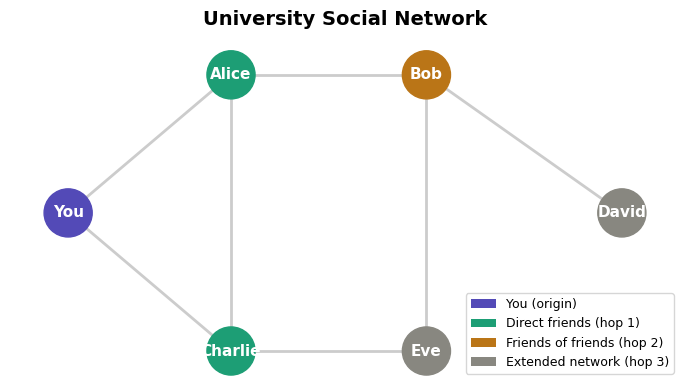

Nodes : 6
Edges : 7
Density: 0.467


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Consistent figure style
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Build the university social graph ──────────────────────────────────────
G = nx.Graph()

nodes = ['You', 'Alice', 'Bob', 'Charlie', 'David', 'Eve']
edges = [
    ('You', 'Alice'),
    ('You', 'Charlie'),
    ('Alice', 'Bob'),
    ('Alice', 'Charlie'),
    ('Bob', 'David'),
    ('Bob', 'Eve'),
    ('Charlie', 'Eve'),
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

# ── Node colours by distance from 'You' ────────────────────────────────────
color_map = {
    'You':     '#534AB7',
    'Alice':   '#1D9E75',
    'Charlie': '#1D9E75',
    'Bob':     '#BA7517',
    'David':   '#888780',
    'Eve':     '#888780',
}
node_colors = [color_map[n] for n in G.nodes()]

pos = {
    'You':     (0,   1),
    'Alice':   (1,   2),
    'Charlie': (1,   0),
    'Bob':     (2.2, 2),
    'Eve':     (2.2, 0),
    'David':   (3.4, 1),
}

fig, ax = plt.subplots(figsize=(7, 4))
nx.draw_networkx(
    G, pos, ax=ax,
    node_color=node_colors, node_size=1200,
    font_color='white', font_weight='bold', font_size=11,
    edge_color='#cccccc', width=2,
)

legend_elements = [
    mpatches.Patch(facecolor='#534AB7', label='You (origin)'),
    mpatches.Patch(facecolor='#1D9E75', label='Direct friends (hop 1)'),
    mpatches.Patch(facecolor='#BA7517', label='Friends of friends (hop 2)'),
    mpatches.Patch(facecolor='#888780', label='Extended network (hop 3)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('University Social Network', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density: {nx.density(G):.3f}")

## Applications of Graphs

Graphs are not just academic; they power real-world systems:

- **Navigation (Google Maps):** Road networks are weighted directed graphs: nodes are intersections, edges are road segments, weights are travel times that update in real time from GPS data. Dijkstra and A* (which uses geographic distance as a heuristic to guide search) find your route. The challenge is scale: the US road network has ~50 million nodes.
> Nodes → locations, Edges → roads (Used for shortest path).  
- **Social Networks:** Facebook's social graph had ~3 billion nodes at last public reporting. It powers friend recommendations (who shares many mutual friends with you?), feed ranking, and ad targeting. The graph is stored in a custom distributed system called TAO.
> Nodes → users, Edges → connections  (Used for recommendations).

- **Recommendation Systems:** Graphs like "Bipartite" (where every edge connects a vertex from one set to a vertex from the other set.) connect users to items they've interacted with. Collaborative filtering (we will discuss this in *later chapter*) asks: which items are connected to users similar to you? More sophisticated approaches use graph neural networks that propagate information through multi-hop neighborhoods.
Web search and PageRank

> Nodes → users + products,Edges → interactions  
- **Web Search:** The web is a directed graph with ~60 trillion pages. PageRank assigns each page a score equal to the sum of PageRank scores of pages linking to it, divided by their out-degree — a recursive definition solved as an eigenvector computation. Pages cited by authoritative pages inherit authority.
>Nodes → webpages, Edges → hyperlinks  

- **Biology and medicine:** Protein-protein interaction networks reveal which proteins work together. Metabolic networks model how cells convert nutrients to energy. Drug repurposing finds new uses for existing drugs by identifying proteins structurally close to a disease target in the interaction graph. Graph neural networks now power breakthrough protein structure prediction tools.

- **Fraud detection**: Financial transaction graphs detect anomalous patterns — cycles of transactions that suggest money laundering, or suspicious clustering of accounts. Graph-based features dramatically outperform purely tabular approaches for this problem.



| Domain | Nodes | Edges | Algorithm used |
|--------|-------|-------|----------------|
| **Navigation** (Google Maps) | Intersections | Roads | Dijkstra / A* |
| **Social Networks** (Facebook) | Users | Friendships | Community detection, BFS |
| **Recommendations** (Netflix) | Users + Movies | Ratings/views | Collaborative filtering, GNN |
| **Web Search** (Google) | Web pages | Hyperlinks | PageRank |
| **Biology** | Proteins | Interactions | Centrality, clustering |
| **Fraud Detection** | Accounts | Transactions | Anomaly detection |
| **Supply Chain** | Warehouses/ports | Routes | Min-cost flow |

## Graph Processing

Once we build a graph, we analyze it.

### Common Tasks:
- **Traversal (BFS, DFS)**: Systematically explore all nodes and edges in a graph.
- **Shortest Path**: Find the minimum-cost route between two nodes.
- **Community Detection**: Identify groups of densely connected nodes.
- **Ranking nodes**: Measure and rank node importance based on structure
- **Link prediction**: Predict likely future or missing connections between nodes.

> Insight: Graph processing = turning connections into decisions

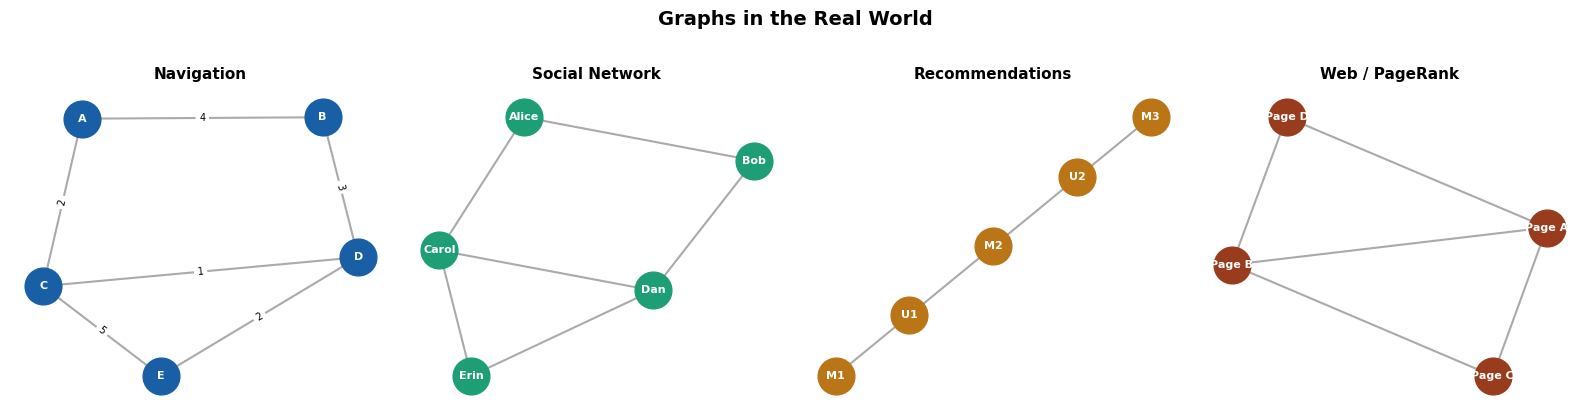

In [ ]:
# ── Visualise four application domains side by side ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Graphs in the Real World', fontsize=14, fontweight='bold', y=1.02)

configs = [
    {
        'title': 'Navigation',
        'nodes': ['A','B','C','D','E'],
        'edges': [('A','B',4),('A','C',2),('B','D',3),('C','D',1),('C','E',5),('D','E',2)],
        'color': '#185FA5',
        'weighted': True,
    },
    {
        'title': 'Social Network',
        'nodes': ['Alice','Bob','Carol','Dan','Erin'],
        'edges': [('Alice','Bob'),('Alice','Carol'),('Bob','Dan'),('Carol','Dan'),('Dan','Erin'),('Carol','Erin')],
        'color': '#1D9E75',
        'weighted': False,
    },
    {
        'title': 'Recommendations',
        'nodes': ['U1','U2','M1','M2','M3'],
        'edges': [('U1','M1'),('U1','M2'),('U2','M2'),('U2','M3')],
        'color': '#BA7517',
        'weighted': False,
    },
    {
        'title': 'Web / PageRank',
        'nodes': ['Page A','Page B','Page C','Page D'],
        'edges': [('Page A','Page B'),('Page B','Page C'),('Page C','Page A'),('Page D','Page B'),('Page A','Page D')],
        'color': '#993C1D',
        'weighted': False,
    },
]

for ax, cfg in zip(axes, configs):
    if cfg['weighted']:
        Gi = nx.Graph()
        Gi.add_nodes_from(cfg['nodes'])
        for u, v, w in cfg['edges']:
            Gi.add_edge(u, v, weight=w)
    else:
        Gi = nx.Graph()
        Gi.add_nodes_from(cfg['nodes'])
        Gi.add_edges_from(cfg['edges'])

    pos_i = nx.spring_layout(Gi, seed=42)
    nx.draw_networkx(
        Gi, pos_i, ax=ax,
        node_color=cfg['color'], node_size=700,
        font_color='white', font_size=8, font_weight='bold',
        edge_color='#aaaaaa', width=1.5,
        arrows=('Page' in cfg['nodes'][0]),
    )
    if cfg['weighted']:
        labels = nx.get_edge_attributes(Gi, 'weight')
        nx.draw_networkx_edge_labels(Gi, pos_i, edge_labels=labels, ax=ax, font_size=7)
    ax.set_title(cfg['title'], fontsize=11, fontweight='bold', pad=8)
    ax.axis('off')

plt.tight_layout()
plt.show()


## Representing Graphs: 3 Ways to Store a Graph

Before running any algorithm, you must choose a data structure (because you need to store the graph). The right choice depends on the graph's **size**, **density**, and what **operations** you need to perform fast.

### Summary

| Property           | Adjacency Matrix        | Adjacency List                     | Adjacency Dictionary              |
|-------------------|------------------------|------------------------------------|-----------------------------------|
| Space             | O(V²)                  | O(V + E)                           | O(V + E)                          |
| Edge lookup       | O(1)                   | O(degree)                          | O(1) average                      |
| Iterate neighbors | O(V)                   | O(degree)                          | O(degree)                         |
| Best for          | Dense graphs, fast lookups | Sparse graphs (most real-world) | Fast lookups with flexible structure |
| Worst for         | Large sparse graphs    | Edge weight matrix                 | Slight overhead due to hashing     |


### (1) Adjacency Matrix

An **N × N** matrix where `M[i][j] = 1` (or the edge weight) if an edge exists from node i to node j, otherwise 0.

- Edge existence check in **O(1)**
- Wastes **O(V²)** memory — 1 million nodes = 10¹² entries

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251028181828547875/1-.webp" width="500"/>
</p>

<p align="center">
  <em>Adjacency Matrix. Source: GeeksforGeeks</em><br>
</p>

```python
# 4 nodes: You=0, Alice=1, Bob=2, Charlie=3
adj_matrix = [
    [0, 1, 0, 1],  # You connects to Alice and Charlie
    [1, 0, 1, 1],  # Alice connects to You, Bob, Charlie
    [0, 1, 0, 0],  # Bob connects to Alice
    [1, 1, 0, 0],  # Charlie connects to You and Alice
]
```

### (2) Adjacency List

Each node stores a **list of its neighbors**. Only edges that exist take up memory.

- Space efficient: **O(V + E)** - far more efficient for sparse graphs (most real-world graphs have far fewer edges than the maximum possible).

- Fast neighbor iteration — most graph algorithms use this
- Checking if a specific edge exists requires scanning the neighbor list: **O(degree)**

<p align="center">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20251028181956953251/file.webp" width="500"/>
</p>

<p align="center">
  <em>Adjacency List. Source: GeeksforGeeks</em><br>
</p>


```python
graph = {
    'You':     ['Alice', 'Charlie'],
    'Alice':   ['You', 'Bob', 'Charlie'],
    'Bob':     ['Alice', 'David'],
    'Charlie': ['You', 'Alice', 'Eve'],
    'David':   ['Bob'],
    'Eve':     ['Bob', 'Charlie'],
}
```
Real-world graphs use libraries like [NetworkX](https://networkx.org/) (Python), [igraph](https://igraph.org/), or graph databases like [Neo4j](https://neo4j.com/) for billion-edge scale.

### (3) Adjacency Dictionary

An **adjacency dictionary** is a dict-of-dicts. It stores each node and its neighbors as **key–value pairs**.

- Outer key → node  
- Inner key → neighbor  
- Inner value → weight (or 1 if unweighted)

Some key advantages:
- Fast edge lookup → average **O(1)**  
- Naturally supports **weighted graphs**  
- Flexible for storing extra information (distance, cost, frequency)

> **Intuition**: *Adjacency List* = simple neighbors ; *Adjacency Dictionary* = neighbors + extra information

```python
graph_weighted = {
    'You':     {'Alice': 2, 'Charlie': 1},
    'Alice':   {'You': 2, 'Bob': 3, 'Charlie': 2},
    'Bob':     {'Alice': 3, 'David': 4},
    'Charlie': {'You': 1, 'Alice': 2, 'Eve': 5},
    'David':   {'Bob': 4},
    'Eve':     {'Bob': 2, 'Charlie': 5},
}

```

Compared to an adjacency list (dict of lists):

| Operation | Adj. List | Adj. Dictionary |
|-----------|-----------|-----------------|
| Space | O(V + E) | O(V + E) |
| Check if edge (u,v) exists | O(degree(u)) | **O(1)** |
| Get weight of edge (u,v) | O(degree(u)) | **O(1)** |
| Add edge | O(1) append | O(1) assign |
| Remove edge | O(degree) | **O(1)** del |
| Iterate neighbors of u | O(degree) | O(degree) |

> This is the representation used internally by **NetworkX** (`G._adj`) and by most production graph libraries.

Variants:
- **Unweighted** — inner value is `1` (or `{}`) — just tracks existence
- **Weighted** — inner value is a number (distance, cost, probability)
- **Attributed** — inner value is a dict holding multiple properties per edge



=== Adjacency Matrix ===
         You  Alice  Bob  Charlie  David  Eve
You        0      1    0        1      0    0
Alice      1      0    1        1      0    0
Bob        0      1    0        0      1    1
Charlie    1      1    0        0      0    1
David      0      0    1        0      0    0
Eve        0      0    1        1      0    0


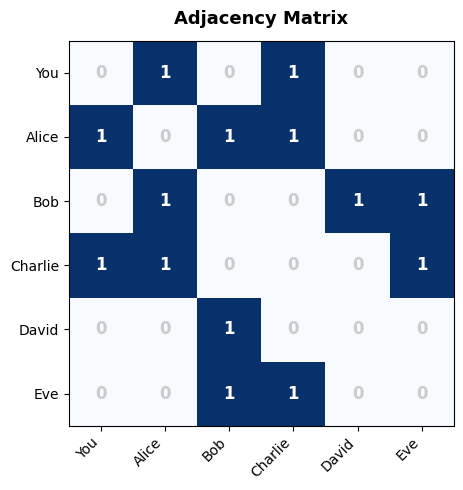


Matrix size  : 6×6 = 36 cells
Non-zero     : 14 (edges × 2 for undirected)
Sparsity     : 61.1%  ← most cells are wasted zeros


In [ ]:
# ── Adjacency Matrix ─────────────────────────────────────────────────────────
node_list = ['You', 'Alice', 'Bob', 'Charlie', 'David', 'Eve']
n = len(node_list)
idx = {name: i for i, name in enumerate(node_list)}

adj_matrix = np.zeros((n, n), dtype=int)
for u, v in edges:
    adj_matrix[idx[u]][idx[v]] = 1
    adj_matrix[idx[v]][idx[u]] = 1   # undirected

df_matrix = pd.DataFrame(adj_matrix, index=node_list, columns=node_list)
print("=== Adjacency Matrix ===")
print(df_matrix)

# Visualise as heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(adj_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(node_list, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(node_list, fontsize=10)
for i in range(n):
    for j in range(n):
        ax.text(j, i, adj_matrix[i][j], ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if adj_matrix[i][j] else '#cccccc')
ax.set_title('Adjacency Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

sparsity = 1 - (adj_matrix.sum() / adj_matrix.size)
print(f"\nMatrix size  : {n}×{n} = {n*n} cells")
print(f"Non-zero     : {int(adj_matrix.sum())} (edges × 2 for undirected)")
print(f"Sparsity     : {sparsity:.1%}  ← most cells are wasted zeros")

In [ ]:
# ── Adjacency List ───────────────────────────────────────────────────────────
adj_list = {node: [] for node in node_list}

for u, v in edges:
    adj_list[u].append(v)
    adj_list[v].append(u)   # undirected

print("=== Adjacency List ===")
for node, neighbors in adj_list.items():
    print(f"  {node:8s} → {neighbors}")

total_entries = sum(len(v) for v in adj_list.values())
print(f"\nTotal entries stored: {total_entries}  (= 2×|E| = 2×{len(edges)})")
print(f"vs adjacency matrix : {n*n} entries")
print(f"Memory saving       : {1 - total_entries/(n*n):.1%} fewer entries")

=== Adjacency List ===
  You      → ['Alice', 'Charlie']
  Alice    → ['You', 'Bob', 'Charlie']
  Bob      → ['Alice', 'David', 'Eve']
  Charlie  → ['You', 'Alice', 'Eve']
  David    → ['Bob']
  Eve      → ['Bob', 'Charlie']

Total entries stored: 14  (= 2×|E| = 2×7)
vs adjacency matrix : 36 entries
Memory saving       : 61.1% fewer entries


In [ ]:
# ── Adjacency Dictionary — three flavours ────────────────────────────────────

# 1. Unweighted (value = 1, just marks edge existence)
adj_dict_unweighted = {
    'You':     {'Alice': 1, 'Charlie': 1},
    'Alice':   {'You': 1, 'Bob': 1, 'Charlie': 1},
    'Bob':     {'Alice': 1, 'David': 1, 'Eve': 1},
    'Charlie': {'You': 1, 'Alice': 1, 'Eve': 1},
    'David':   {'Bob': 1},
    'Eve':     {'Bob': 1, 'Charlie': 1},
}

# 2. Weighted (value = edge weight)
adj_dict_weighted = {
    'You':     {'Alice': 0.9, 'Charlie': 0.7},
    'Alice':   {'You': 0.9, 'Bob': 0.5, 'Charlie': 0.8},
    'Bob':     {'Alice': 0.5, 'David': 0.6, 'Eve': 0.4},
    'Charlie': {'You': 0.7, 'Alice': 0.8, 'Eve': 0.3},
    'David':   {'Bob': 0.6},
    'Eve':     {'Bob': 0.4, 'Charlie': 0.3},
}

# 3. Attributed (value = dict with multiple properties per edge)
adj_dict_attributed = {
    'You':   {'Alice':   {'weight': 0.9, 'since': 2023, 'context': 'orientation'},
              'Charlie': {'weight': 0.7, 'since': 2023, 'context': 'class'}},
    'Alice': {'You':     {'weight': 0.9, 'since': 2023, 'context': 'orientation'},
              'Bob':     {'weight': 0.5, 'since': 2023, 'context': 'introduction'},
              'Charlie': {'weight': 0.8, 'since': 2023, 'context': 'class'}},
    # ... (truncated for brevity)
}

# ── O(1) operations ───────────────────────────────────────────────────────────
g = adj_dict_weighted

print("=== O(1) edge operations ===")
print(f"Edge (You, Alice) exists?    {'Alice' in g['You']}")          # O(1)
print(f"Edge (You, David) exists?    {'David' in g['You']}")          # O(1)
print(f"Weight of (Alice, Bob):      {g['Alice']['Bob']}")             # O(1)
print(f"Degree of Alice:             {len(g['Alice'])}")               # O(1)

print("\n=== Adding and removing edges ===")
g['David']['Eve'] = 0.2          # add a new edge        O(1)
print(f"After adding David-Eve:      {list(g['David'].keys())}")

del g['David']['Eve']            # remove it             O(1)
print(f"After removing David-Eve:    {list(g['David'].keys())}")

print("\n=== Iterating neighbors ===")
for neighbor, weight in g['Alice'].items():           # O(degree)
    print(f"  Alice → {neighbor:8s}  weight={weight}")

=== O(1) edge operations ===
Edge (You, Alice) exists?    True
Edge (You, David) exists?    False
Weight of (Alice, Bob):      0.5
Degree of Alice:             3

=== Adding and removing edges ===
After adding David-Eve:      ['Bob', 'Eve']
After removing David-Eve:    ['Bob']

=== Iterating neighbors ===
  Alice → You       weight=0.9
  Alice → Bob       weight=0.5
  Alice → Charlie   weight=0.8



# Graph Featurization

Raw graph structure alone is not always enough for machine learning. **Featurization** converts graph structure and node/edge properties into numeric vectors that models can consume.

## Why Featurization?

Graphs are inherently relational, but most ML models expect **fixed-size numeric inputs**. Featurization bridges this gap.

## Types of Graph Features
There are four main types:

| Type | What it captures | Examples |
|------|-----------------|----------|
| **1. Graph-level features** | Properties of the whole graph | Diameter, density, spectral features |
| **2. Edge features** | Properties of connections | Weight, transaction amount, timestamp |
| **3. Node features** | Properties of individual nodes | Age, degree, label |
| **Structural features** | Topological role of a node | Centrality, clustering coefficient, motif count |


> In Graph Neural Networks, the model learns to aggregate these features across multi-hop neighborhoods automatically.


### 1. Graph-Level Features (Global View)

Describe the **entire graph as a whole**.

### What they capture:
- Overall connectivity
- Global structure
- Network complexity

### Common Features:
- **Diameter** → longest shortest path in the graph  
- **Average path length** → average distance between nodes  
- **Density** → how many edges exist vs possible edges  
- **Modularity** → strength of community structure  

### Example:
- Social network: **High density** → many people are connected; **Low diameter** → information spreads quickly.
- Used in: Graph classification (e.g., molecule type, network type)


### 2. Edge-Level Features (Relationship View)

Describe **connections between two nodes**.

### What they capture:
- Strength or nature of relationships  
- Likelihood of future connections  

### Common Features:
- **Weight** → distance, cost, interaction frequency  
- **Common neighbors** → shared connections  
- **Jaccard similarity** → similarity between neighborhoods  
- **Edge betweenness** → importance of an edge  

### Example:
- E-commerce:
  - Edge = user → product  
  - Weight = number of purchases  
- Social network:
  - Two users with many common friends → high similarity  

Used in: Link prediction, Recommendation systems, Fraud detection.  


### 3. Node-Level Features (Local View — Focus)

Describe **individual nodes**. There are two ways - via "Degree" and via "Centrality"

#### (a) **Degree**:
Number of connections a node has  
**Types:**
- **In-degree** → incoming edges  
- **Out-degree** → outgoing edges  

### Example:
- Twitter:
  - High in-degree → many followers  
  - High out-degree → follows many people  

> **Interpretation**:High degree → more connected → potentially more influence  


#### (b) **Centrality** (Covered Next Section)

Centrality measures capture **node importance** in the network.

- **Degree Centrality**: Measures importance based on the number of direct connections a node has.  
- **Closeness Centrality**: Measures how quickly a node can reach all other nodes in the network.  
- **Betweenness Centrality**: Measures how often a node lies on the shortest paths between other nodes (bridge nodes).  
- **Eigenvector Centrality**: Measures importance by considering not just connections, but how important those neighbors are.


## 4. Structural Features (Topological Role)

Describe how a node is positioned in the **overall structure**.

### What they capture:
- Local neighborhood patterns  
- Role of node in graph structure  

### Common Features:
- **Clustering coefficient** → how connected neighbors are  
- **Triangle count** → number of triangles a node participates in  
- **Motifs** → recurring subgraph patterns  

### Example:
- Social network:High clustering → tight friend group  
- Fraud detection: Unusual patterns → suspicious behavior  




=== Node Feature Matrix (structural features) ===
         Degree  Clustering Coeff  Closeness Centrality  Betweenness Centrality  Avg Neighbor Degree
Node                                                                                                
You         2.0             1.000                 0.556                    0.00                 3.00
Alice       3.0             0.333                 0.714                    0.30                 2.67
Bob         3.0             0.000                 0.714                    0.45                 2.00
Charlie     3.0             0.333                 0.625                    0.15                 2.33
David       1.0             0.000                 0.455                    0.00                 3.00
Eve         2.0             0.000                 0.625                    0.10                 3.00


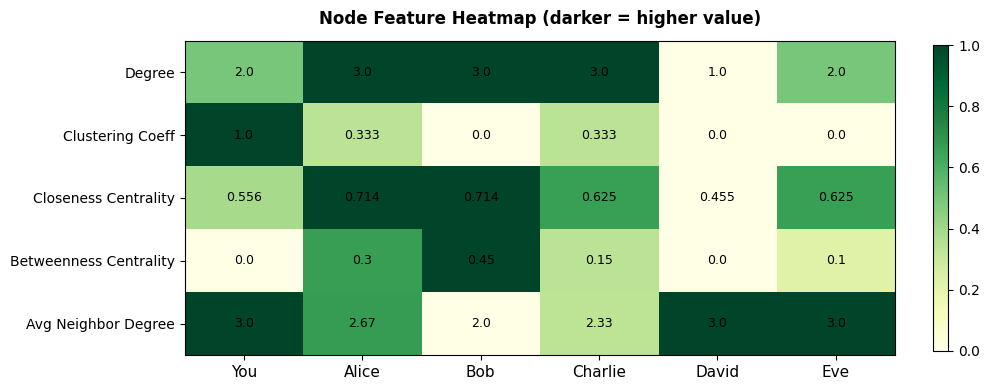

In [ ]:
# ── Build a feature table for each node ─────────────────────────────────────
features = {}
for node in G.nodes():
    deg   = G.degree(node)
    cc    = nx.clustering(G, node)
    close = nx.closeness_centrality(G, node)
    betw  = nx.betweenness_centrality(G)[node]
    neigh_degrees = [G.degree(nb) for nb in G.neighbors(node)]
    avg_nb_deg = np.mean(neigh_degrees) if neigh_degrees else 0

    features[node] = {
        'Degree':                      deg,
        'Clustering Coeff':            round(cc,   3),
        'Closeness Centrality':        round(close,3),
        'Betweenness Centrality':      round(betw, 3),
        'Avg Neighbor Degree':         round(avg_nb_deg, 2),
    }

df_features = pd.DataFrame(features).T
df_features.index.name = 'Node'
print("=== Node Feature Matrix (structural features) ===")
print(df_features.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
data_norm = df_features.apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9))
im = ax.imshow(data_norm.T.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(df_features)))
ax.set_yticks(range(len(df_features.columns)))
ax.set_xticklabels(df_features.index, fontsize=11)
ax.set_yticklabels(df_features.columns, fontsize=10)
for i, col in enumerate(df_features.columns):
    for j, node in enumerate(df_features.index):
        ax.text(j, i, df_features.loc[node, col], ha='center', va='center', fontsize=9)
ax.set_title('Node Feature Heatmap (darker = higher value)', fontsize=12, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.show()

## Centrality Measures ( Node Importance)

Not all nodes are equal. Some nodes connect many others; some nodes act as bridges and some nodes are closer to everyone.  

**Centrality measures** quantify **how important or influential a node is** within a graph (or network).


> **Key insight:** Different centrality metrics answer different questions about importance. A node can rank #1 on one metric and #5 on another.


We will cover three foundational measures:

| Measure | Core question | Analogy |
|---------|--------------|--------|
| **Degree centrality** | How many direct connections? | Popularity |
| **Closeness centrality** | How quickly can you reach everyone? | Efficiency |
| **Betweenness centrality** | How often do you sit on the shortest path between others? | Broker / gatekeeper |

<p align="center">
  <img src="https://towardsdatascience.com/wp-content/uploads/2020/08/1gdH6JmSIOf0JxtNWhN6yjg.png" width="550"/>
</p>

<p align="center">
  <em>Illustration of different centrality roles in a network. Source: towardsdatascience.com</em>
</p>


### 1. Degree Centrality

The simplest measure. Measures importance based on **number of direct connections**.

A node's degree centrality is its **number of edges divided by the maximum possible edges**.

> **Example:** who has the *most connections*? Alice and Bob tie in our example. In a social network, a person with many friends has high degree centrality  


$$C_D(v) = \frac{\deg(v)}{N - 1}$$

where N is the total number of nodes.


- High degree → directly connected to many nodes → "popular" or "well-networked"
- Fast to compute: **O(V + E)**
- Limitation: ignores the quality/importance of connections (a node connected to 10 isolated nodes vs. 10 hubs)


### 2. Closeness Centrality

Measures how **close a node is to all other nodes**. It focus on how **quickly** a node can reach all others (based on shortest path). A node is close-central if its average shortest path to every other node is short.

> **Example:** who can reach everyone else *most quickly on average*? A node that can quickly reach everyone (few hops) has high closeness.



$$C_C(v) = \frac{N - 1}{\sum_{u \neq v} d(v, u)}$$

where $d(v, u)$ is the shortest path length between nodes v and u.


<p align="center">
  <img src="https://www.ebi.ac.uk/training/online/courses/network-analysis-of-protein-interaction-data-an-introduction/wp-content/uploads/sites/64/2020/08/new-fig-28-1024x638.png" width="400"/>
</p>

<p align="center">
  <em>Nodes with high closeness are closer (shorter paths) to all others.Source: www.ebi.ac.uk</em>
</p>



- High closeness → information/influence spreads **fast** from this node
- In a social network: the person who hears gossip first, or spreads news fastest
- In a supply chain: the warehouse that can ship to any destination quickest
- Complexity: **O(V × (V + E))** using BFS from each node


### 3. Betweenness Centrality

Measures how often a node acts as a **bridge** along the shortest path between two other nodes.

> How often a node lies on **shortest paths between other nodes**. Identifies **bridge nodes**

> **Example:** who is *connected to other well-connected nodes*? This is the core idea behind Google's PageRank. A person connecting two groups has high betweenness  

$$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

where:
- $\sigma_{st}$ = total number of shortest paths from s to t
- $\sigma_{st}(v)$ = number of those paths that pass through v

**Notes:** The normalized version divides by $(N-1)(N-2)/2$ so scores fall in [0, 1]. But in this course, we are not doing it.


- High betweenness → **gatekeeper / broker** — controls information flow
- Removing a high-betweenness node disrupts the network most
- Used in: fraud detection (unusual intermediaries), infrastructure resilience, influence campaigns
- Complexity: **O(VE)** (Brandes algorithm)


## When to Use Which?

- Degree → quick measure of connectivity  
- Closeness → efficiency of communication  
- Betweenness → control over information flow  
- Eigenvector → influence in the network  


## Connection to Featurization

Centrality measures are **node-level features** used in:
- Recommendation systems  
- Social network analysis  
- Fraud detection  
- Graph-based machine learning  

These features help models understand **node importance and role**

In [ ]:
import networkx as nx

G = nx.Graph()
G.add_edges_from([
    ("You","Alice"),
    ("You","Charlie"),
    ("Alice","Bob"),
    ("Bob","David"),
    ("Charlie","Eve")
])

print("Degree:", nx.degree_centrality(G))
print("Closeness:", nx.closeness_centrality(G))
print("Betweenness:", nx.betweenness_centrality(G))
print("Eigenvector:", nx.eigenvector_centrality(G))

Degree: {'You': 0.4, 'Alice': 0.4, 'Charlie': 0.4, 'Bob': 0.4, 'David': 0.2, 'Eve': 0.2}
Closeness: {'You': 0.5555555555555556, 'Alice': 0.5555555555555556, 'Charlie': 0.45454545454545453, 'Bob': 0.45454545454545453, 'David': 0.3333333333333333, 'Eve': 0.3333333333333333}
Betweenness: {'You': 0.6000000000000001, 'Alice': 0.6000000000000001, 'Charlie': 0.4, 'Bob': 0.4, 'David': 0.0, 'Eve': 0.0}
Eigenvector: {'You': 0.5211200923556694, 'Alice': 0.5211200923556694, 'Charlie': 0.41790694813836154, 'Bob': 0.41790694813836154, 'David': 0.23192160753344954, 'Eve': 0.23192160753344954}


#Some Example Codes (In Python):

=== Degree Centrality ===
Formula: C_D(v) = degree(v) / (N - 1) = degree(v) / 5

  Alice     0.600  ██████████████████  [degree=3]
  Bob       0.600  ██████████████████  [degree=3]
  Charlie   0.600  ██████████████████  [degree=3]
  You       0.400  ████████████  [degree=2]
  Eve       0.400  ████████████  [degree=2]
  David     0.200  ██████  [degree=1]


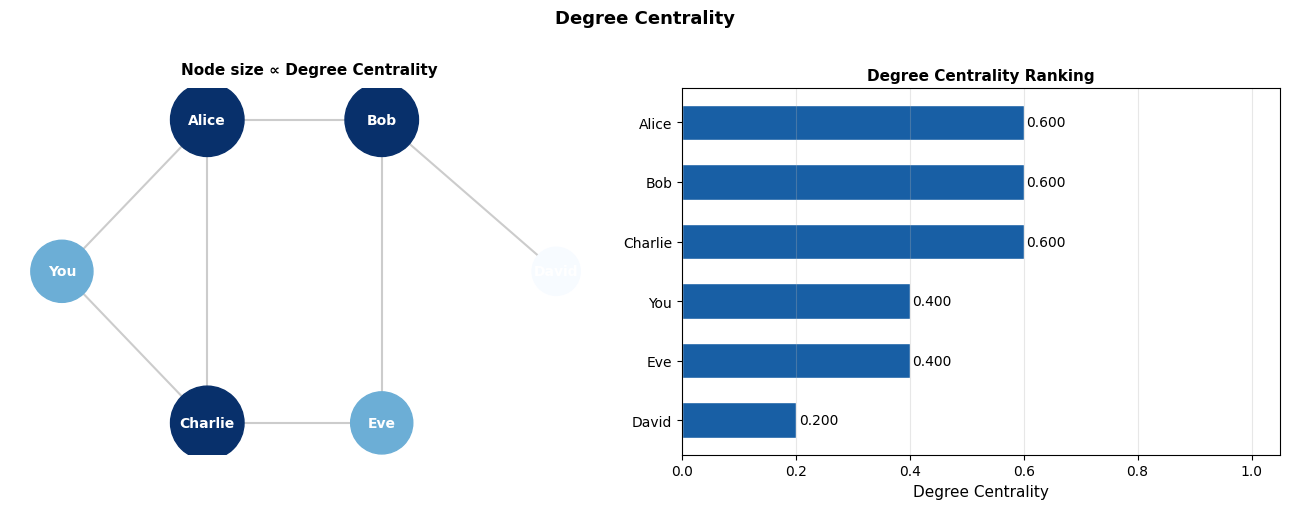

In [ ]:
# ── Degree Centrality ────────────────────────────────────────────────────────
deg_centrality = nx.degree_centrality(G)

print("=== Degree Centrality ===")
print(f"Formula: C_D(v) = degree(v) / (N - 1) = degree(v) / {G.number_of_nodes()-1}\n")
for node, score in sorted(deg_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 30)
    print(f"  {node:8s}  {score:.3f}  {bar}  [degree={G.degree(node)}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph with node size ∝ degree centrality
sizes = [deg_centrality[n] * 4000 + 400 for n in G.nodes()]
colors = [deg_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Blues',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Degree Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(deg_centrality, key=deg_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [deg_centrality[n] for n in sorted_nodes],
    color='#185FA5', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = deg_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Degree Centrality', fontsize=11)
axes[1].set_title('Degree Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Degree Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Shortest paths from Alice to all others ===
  Alice → You     : 1 hop(s)
  Alice → Bob     : 1 hop(s)
  Alice → Charlie : 1 hop(s)
  Alice → David   : 2 hop(s)
  Alice → Eve     : 2 hop(s)

  Sum of distances = 7
  Closeness(Alice) = (N-1) / sum = 5/7 = 0.714

=== All Closeness Centralities ===
  Alice     0.714  █████████████████████
  Bob       0.714  █████████████████████
  Charlie   0.625  ██████████████████
  Eve       0.625  ██████████████████
  You       0.556  ████████████████
  David     0.455  █████████████


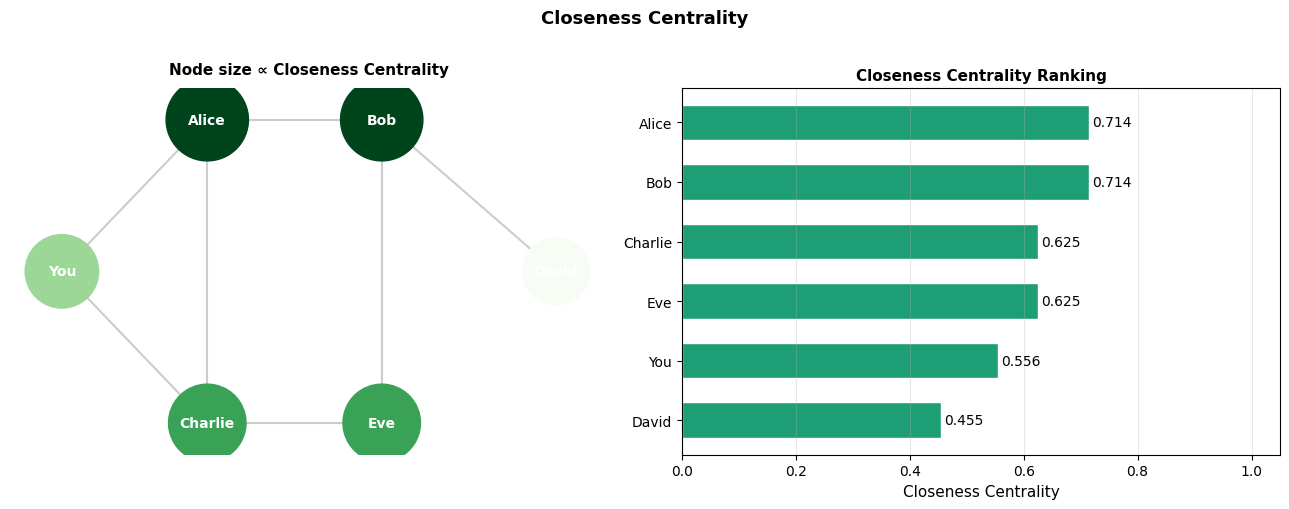

In [ ]:
# ── Closeness Centrality ─────────────────────────────────────────────────────
close_centrality = nx.closeness_centrality(G)

# Show the shortest path distances from Alice to understand the formula
print("=== Shortest paths from Alice to all others ===")
lengths = nx.single_source_shortest_path_length(G, 'Alice')
total_dist = sum(v for k, v in lengths.items() if k != 'Alice')
alice_closeness = (G.number_of_nodes() - 1) / total_dist
for target, dist in lengths.items():
    if target != 'Alice':
        print(f"  Alice → {target:8s}: {dist} hop(s)")
print(f"\n  Sum of distances = {total_dist}")
print(f"  Closeness(Alice) = (N-1) / sum = {G.number_of_nodes()-1}/{total_dist} = {alice_closeness:.3f}")

print("\n=== All Closeness Centralities ===")
for node, score in sorted(close_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 30)
    print(f"  {node:8s}  {score:.3f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph
sizes = [close_centrality[n] * 4500 + 300 for n in G.nodes()]
colors = [close_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Greens',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Closeness Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(close_centrality, key=close_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [close_centrality[n] for n in sorted_nodes],
    color='#1D9E75', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = close_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Closeness Centrality', fontsize=11)
axes[1].set_title('Closeness Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Closeness Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Paths that pass through Alice ===
  You → Alice → Bob
  You → Alice → Bob → David
  Bob → Alice → You
  Bob → Alice → Charlie
  Charlie → Alice → Bob
  Charlie → Alice → Bob → David
  David → Bob → Alice → You
  David → Bob → Alice → Charlie

=== All Betweenness Centralities ===
  Bob       0.450  ███████████████████████████
  Alice     0.300  ██████████████████
  Charlie   0.150  █████████
  Eve       0.100  ██████
  You       0.000  
  David     0.000  


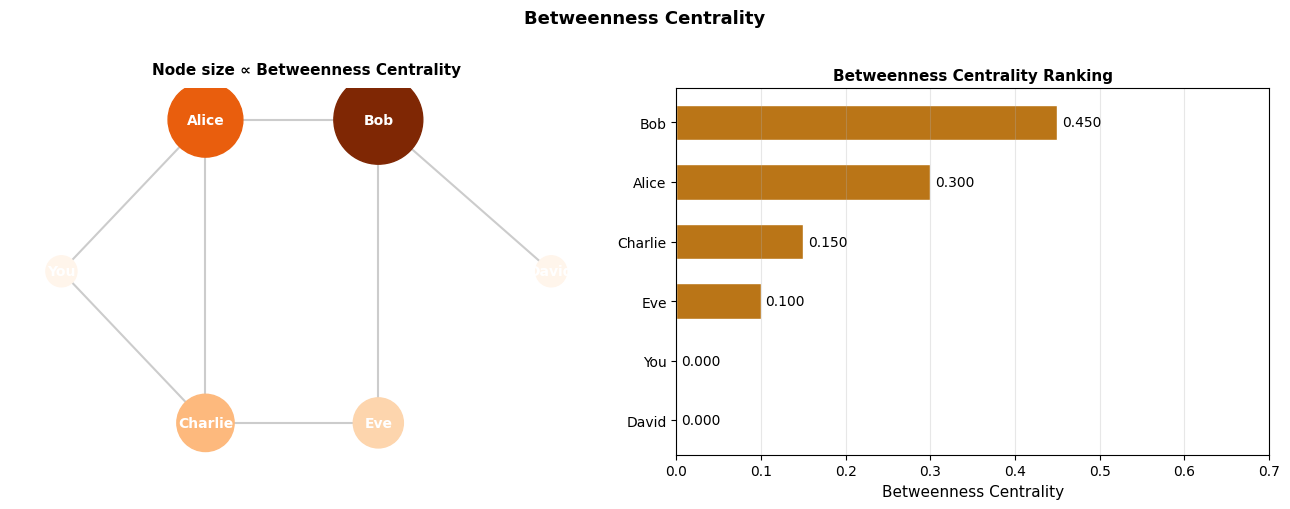

In [ ]:
# ── Betweenness Centrality ───────────────────────────────────────────────────
betw_centrality = nx.betweenness_centrality(G, normalized=True)

# Manually show which paths pass through Alice
print("=== Paths that pass through Alice ===")
all_pairs = list(nx.all_pairs_shortest_path(G))
through_alice = []
for src, paths in all_pairs:
    for dst, path in paths.items():
        if src != dst and 'Alice' in path[1:-1]:   # middle of path
            through_alice.append(f"{src} → {' → '.join(path[1:])}")
for p in through_alice:
    print(f"  {p}")

print("\n=== All Betweenness Centralities ===")
for node, score in sorted(betw_centrality.items(), key=lambda x: -x[1]):
    bar = '█' * int(score * 60)
    print(f"  {node:8s}  {score:.3f}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: graph, highlight high-betweenness nodes
sizes  = [betw_centrality[n] * 8000 + 500 for n in G.nodes()]
colors = [betw_centrality[n] for n in G.nodes()]
nx.draw_networkx(
    G, pos, ax=axes[0],
    node_size=sizes, node_color=colors, cmap='Oranges',
    font_color='white', font_weight='bold', font_size=10,
    edge_color='#cccccc', width=1.5,
)
axes[0].set_title('Node size ∝ Betweenness Centrality', fontsize=11, fontweight='bold', pad=10)
axes[0].axis('off')

# Right: bar chart
sorted_nodes = sorted(betw_centrality, key=betw_centrality.get, reverse=True)
axes[1].barh(
    sorted_nodes,
    [betw_centrality[n] for n in sorted_nodes],
    color='#BA7517', edgecolor='white', height=0.6
)
for i, node in enumerate(sorted_nodes):
    v = betw_centrality[node]
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)
axes[1].set_xlabel('Betweenness Centrality', fontsize=11)
axes[1].set_title('Betweenness Centrality Ranking', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 0.7)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Betweenness Centrality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

=== Centrality Comparison Table ===
         Degree  Closeness  Betweenness
Node                                   
Bob         0.6      0.714         0.45
Alice       0.6      0.714         0.30
Charlie     0.6      0.625         0.15
Eve         0.4      0.625         0.10
You         0.4      0.556         0.00
David       0.2      0.455         0.00


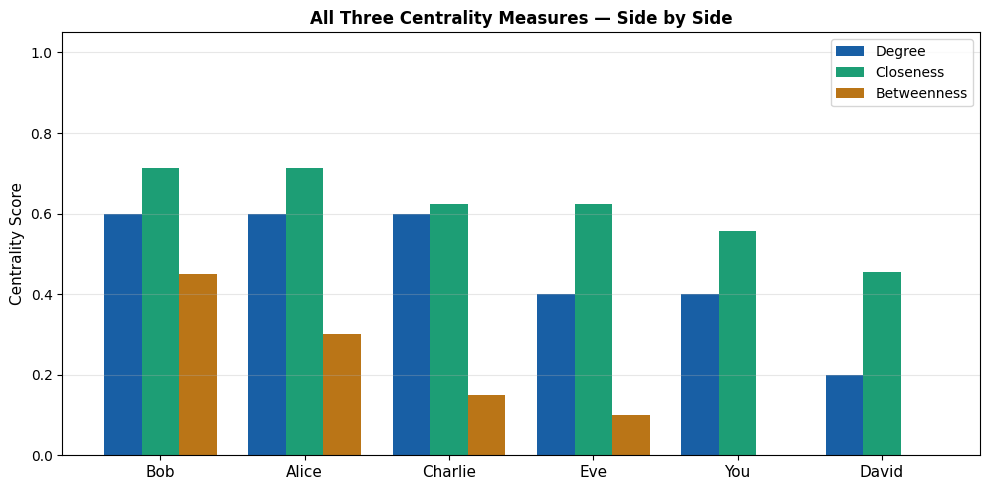


=== Key Takeaways ===
  Most connected (Degree)     : Alice
  Fastest to reach all (Close): Alice
  Biggest bridge (Between)    : Bob


In [ ]:
### Centrality Comparison: All Three Measures

# ── Side-by-side comparison of all three centralities ──────────────────────
df_centrality = pd.DataFrame({
    'Degree':      deg_centrality,
    'Closeness':   close_centrality,
    'Betweenness': betw_centrality,
}).round(3)
df_centrality.index.name = 'Node'
print("=== Centrality Comparison Table ===")
print(df_centrality.sort_values('Betweenness', ascending=False).to_string())

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(node_list))
w = 0.26
nodes_sorted = df_centrality.sort_values('Betweenness', ascending=False).index.tolist()

ax.bar(x - w, [df_centrality.loc[n,'Degree']      for n in nodes_sorted], w, label='Degree',      color='#185FA5')
ax.bar(x,     [df_centrality.loc[n,'Closeness']   for n in nodes_sorted], w, label='Closeness',   color='#1D9E75')
ax.bar(x + w, [df_centrality.loc[n,'Betweenness'] for n in nodes_sorted], w, label='Betweenness', color='#BA7517')

ax.set_xticks(x)
ax.set_xticklabels(nodes_sorted, fontsize=11)
ax.set_ylabel('Centrality Score', fontsize=11)
ax.set_title('All Three Centrality Measures — Side by Side', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Key Takeaways ===")
print(f"  Most connected (Degree)     : {max(deg_centrality,   key=deg_centrality.get)}")
print(f"  Fastest to reach all (Close): {max(close_centrality, key=close_centrality.get)}")
print(f"  Biggest bridge (Between)    : {max(betw_centrality,  key=betw_centrality.get)}")

# From Centrality to Community Detection

In the previous section, we explored **centrality measures** to understand node importance in a graph. Where we learnt:

-----
- **Degree centrality** tells us which nodes have many direct connections. These nodes are locally important because they interact with many neighbors.
- **Closeness centrality** captures how efficiently a node can reach all other nodes. Nodes with high closeness can spread information quickly across the network.
- **Betweenness centrality** measures how often a node lies on shortest paths between other nodes. These nodes often act as **bridges** connecting different parts of the graph.

---

## Transition: From Important Nodes to Important Edges

So far, we focused on **important nodes**.  Now, we shift our focus slightly:

> Instead of asking *“Which nodes are important?”*, we ask:  
**“Which connections (edges) are critical for holding the network together?”**

This is where the idea of **betweenness** becomes especially powerful.

Nodes with high betweenness sit between groups. Similarly, **edges with high betweenness connect different communities**.


## Community Detection

Real-world graphs are rarely random; nodes cluster into **communities**: groups with dense internal connections and sparse external ones.

Finding these communities reveals friend circles in social networks, topic clusters in citation graphs, functional modules in protein interaction networks, and fraud rings in financial graphs.

### What is a "Community"?

In many real-world networks, nodes naturally organize into **groups**, called **communities**.

> **Informally:** a set of nodes that are more connected to each other than to the rest of the graph.

A **community** is a set of nodes that:
- are **densely connected to each other**  
- have **fewer connections to nodes outside the group**  

Think of friend circles in a social network or research groups in collaboration networks; within a community, there are many internal connections, while only a few edges connect it to other communities.


<p align="center">
  <img src="https://snap.stanford.edu/agm/ncaa.png" width="450"/>
</p>

<p align="center">
  <em>Community structure in an NCAA football network (teams grouped by conferences). Source: Stanford Network Analysis Project (SNAP)</em>
</p>


#### Why Do Communities Form?

Communities arise because:
- People interact more within their group  
- Systems are organized into functional units  
- Networks evolve with localized connections  


The ability to identify these communities through a process called community detection is arguably the most important and practical application of computer algorithms and graph theory.

### Role of Connections Between Communities

While communities are densely connected internally, they are typically linked to other groups by only a **small number of edges**. These edges act as **bridges**, enabling communication across different parts of the network.

From our earlier discussion on centrality:
- **Degree** captures local connectivity  
- **Closeness** reflects how efficiently a node reaches others  
- **Betweenness** identifies nodes or edges that lie on many shortest paths  

> Key Insight:  Edges with **high betweenness** often connect different communities because many shortest paths must pass through them.



### Why Betweenness Reveals Communities

Consider a network with two tightly connected groups and only a few connections between them. These cross-group edges:
- appear frequently in shortest paths  
- carry a large portion of network flow  
- function as bridges between communities  

If we remove these high-betweenness edges, the network naturally separates into distinct clusters.

#### Bridge Edge Example:

<p align="center">
  <img src="https://i.sstatic.net/3lh0G.png" width="450"/>
</p>

<p align="center">
  <em>A small number of edges connect two dense groups (bridge edges)</em>
</p>

#### Community Separation via Edge Removal:
<p align="center">
  <img src="https://miro.medium.com/v2/1*skhjgApyDIPbJNolIZCF5w.png" width="600"/>
</p>

<p align="center">
  <em>Removing high-betweenness edges gradually reveals community structure (Source: Miro Medium)</em>
</p>

> Interpretation:

> **Central edges** → connect different groups; **Removing them** → graph splits into communitie.

<!-- #### Why Betweenness Leads to Communities

Consider a social network with two friend groups:
- Many friendships exist *within* each group  
- Only a few friendships exist *between* the groups  

Those few cross-group edges:
- Appear frequently in shortest paths  
- Have **high betweenness**  
- Act as **bridges** between communities  

If we remove these edges, the network naturally splits into clusters.


<p align="center">
  <img src="https://miro.medium.com/v2/1*skhjgApyDIPbJNolIZCF5w.png" width="600"/>
</p>

<p align="center">
  <em>Removing high-betweenness edges gradually reveals community structure. Souce: Miro.medium</em>
</p> -->

<!-- | Algorithm | Core idea | Time complexity | Best for |
|-----------|-----------|----------------|----------|
| **Girvan–Newman** | Iteratively remove highest-betweenness edges | O(m²n) | Small graphs, hierarchical structure |
| **Louvain** | Greedy modularity maximisation | O(n log n) | Large graphs, fast |
| **Label propagation** | Each node adopts its neighbors' majority label | O(n + m) | Massive graphs |
| **Spectral clustering** | Eigenvectors of graph Laplacian | O(n³) | When structure is geometric | -->

We will deep-dive into the two foundational ideas: **edge betweenness** and the **Girvan–Newman algorithm**, and the quality metric **modularity**.


## Edge Betweenness Centrality

**Edge betweenness** measures how many shortest paths pass through a given edge:

$$C_B(e) = \sum_{s \neq t} \frac{\sigma_{st}(e)}{\sigma_{st}}$$

where $\sigma_{st}$ is the total number of shortest paths from $s$ to $t$, and $\sigma_{st}(e)$ is the number of those paths that use edge $e$.

**Key intuition:** edges that connect two otherwise loosely connected clusters will lie on a huge number of shortest paths. They are the *bridges* between communities. These edges will have very high betweenness scores.

**Algorithm (Brandes):**
1. For each source node $s$, run BFS/Dijkstra to find all shortest paths.
2. Back-propagate path counts along those trees to accumulate edge scores.
3. Repeat for all $n$ source nodes and sum.

Complexity: **O(nm)** for unweighted graphs (n nodes, m edges).

---

### Note for This Course

For simplicity, we will use the **non-normalized version**:

$$
C_B(e) = \sum_{s \neq t} \sigma_{st}(e)
$$

Instead of dividing by $\sigma_{st}$, we simply count how many shortest paths pass through each edge.

---


## Girvan–Newman Algorithm (Core Idea)

The Girvan–Newman algorithm is based on a simple but powerful idea:

> Repeatedly **remove** the most “important” edges to reveal hidden communities.

Proposed by Michelle Girvan and Mark Newman in 2002, this algorithm detects communities by **progressively dismantling the graph**; removing the edges that most bridge communities until the graph splits apart.

**Algorithm steps:**
1. Compute **edge betweenness** for *every edge* in the graph.
2. Identify the edge(s) with the highest betweenness score.
2. Remove that edge(s) from the graph  
3. Recompute edge betweenness for all remaining edges (structure has changed) .
4. Repeat until the graph breaks into the desired number of components (or until all edges are gone).  

As edges are removed, the graph gradually breaks into **separate components**, which correspond to communities.


**Why does this work?**

Edges that connect two communities tend to carry most of the **shortest-path traffic** between them, which gives them very high betweenness values.

In contrast, edges within a community are part of a dense structure, so there are many alternative paths and no single edge is as critical.

As a result, when we remove the edge with the highest betweenness, we are typically cutting a **bridge between communities**, allowing the graph to separate naturally into clusters.


## Computing Edge Betweenness (Intuition)

Edge betweenness answers the question:

> *Which edges are used the most when moving from one node to another?*

Consider a graph that naturally splits into two groups.  To travel from a node on one side to a node on the other, most shortest paths must pass through a **small set of connecting edges**.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*5YZKVVIDZzs_1BUFQtknEg.jpeg" width="600"/>
</p>

<p align="center">
  <em>Edges connecting two groups are used more frequently in shortest paths</em>
</p>

For example, if node 1 wants to reach node 12, a shortest path might look like:

1 → 3 → 7 → 8 → 12  

Here, the edge between nodes **7 and 8** lies on many such paths, making it highly important. Edges like this have **high betweenness** because they carry a large portion of the network’s shortest-path traffic.


---

### Why is Edge Betweenness of (7,8) = 49?

The edge between nodes **7 and 8** connects two large parts of the graph (left and right). Any shortest path from a node on the left to a node on the right must pass through this edge.

- Left side has **7 nodes**: {1,2,3,4,5,6,7}  
- Right side has **7 nodes**: {8,9,10,11,12,13,14}  

The total number of shortest paths between the two sides is:

$$
7 \times 7 = 49
$$

Each pair contributes one shortest path, and all of them pass through edge (7,8).


**Key Insight:**

The edge (7,8) has very high betweenness because:
- it is the **only bridge** between the two halves  
- it carries **all cross-group shortest paths**

This is why it gets the highest score and is removed first in the Girvan–Newman algorithm.

---


To compute edge betweenness, we find shortest paths between all pairs of nodes (e.g., using BFS for unweighted graphs) and count how many times each edge is used. At the end, each edge has a score representing how often it is used.

The edge with the highest score (highest betweenness) is removed, and the process is repeated on the updated graph.

> **Note:** If multiple edges have the same highest value, any one of them can be removed (or all of them together, depending on the implementation).

**Complexity:**

Each edge removal requires recomputing betweenness in **O(nm)** time, and repeating this many times leads to **O(m² n)** overall. Because of this, Girvan–Newman is slow for large graphs, but works well for small networks and for building intuition.


**Output:** The result of the algorithm is a **dendrogram**, a tree-like representation that shows how the graph splits over time.

<p align="center">
  <img src="https://drive.google.com/uc?id=1mmnOmIHbLh8nlHKb_gCzw4QxEVexI387" width="400"/>
</p>
<p align="center">
  <em>Example of a dendrogram showing hierarchical splitting of groups, Source: Jesse Port et al.,Hierarchical clustering of vertebrate communities </em>
</p>


The algorithm starts with the whole graph and gradually splits it into smaller groups. By cutting the tree at different levels, we can obtain a few large communities or many smaller ones.


## Selecting Number of Communities

Wait! Girvan–Newman keeps removing edges. If we remove all edges, every node becomes its own community. So the key question is: **when should we stop?**

<p align="center">
  <img src="https://drive.google.com/uc?id=1cPl8ls0wdwUOJELnZh7T0OEcsliNaNP4" width="500"/>
</p>

<p align="center">
  <em>The graph starts as one group and gradually splits into smaller communities</em>
</p>

One simple approach is to stop when we reach a desired number of groups. This works only if we already know how many communities we expect.

A more flexible approach is to use **modularity**. After each split, we measure how good the community partition is. The partition with the **highest modularity** is considered the best because it has many connections within communities and fewer connections between communities.

## Modularity: Measuring Partition Quality

Girvan–Newman tells us *how* to split a graph, but modularity helps decide *which split is best*. **Modularity** $Q$ measures the quality of a community partition.

$$
Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)
$$

where:
- $m$ = number of edges  
- $A_{ij}$ = 1 if edge $(i,j)$ exists, 0 otherwise  
- $k_i$ = degree of node $i$  
- $\frac{k_i k_j}{2m}$ = expected number of edges between $i$ and $j$ in a random graph  
- $\delta(c_i, c_j)$ = 1 if $i$ and $j$ are in the same community, 0 otherwise  



### Intuition

Modularity compares the number of edges **within communities** to what we would expect by chance:

$$
Q \propto \sum_{\text{communities}} \left( \text{actual edges within group} - \text{expected edges within group} \right)
$$

Higher $Q$ means stronger community structure (more internal connections than expected).

### Interpretation

| Q value | Interpretation |
|---------|----------------|
| < 0 | Worse than random |
| 0 | No clear community structure |
| 0.3 – 0.7 | Meaningful community structure |
| > 0.7 | Very strong community structure (rare) |


> **Stop criterion (Girvan–Newman):** compute $Q$ after each split and choose the partition with the highest value.


### Small Modularity Calculation Example

Consider this graph: A — B      C — D

Edges:  (A–B), (C–D)

So:

- Number of edges: $m = 2$
- Communities:
  - Community 1: {A, B}
  - Community 2: {C, D}


We use:

$$
Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)
$$


#### **Step 1:** Node Degrees

- $k_A = 1$, $k_B = 1$, $k_C = 1$, $k_D = 1$  


#### **Step 2:** Compute for pairs in same community

#### **Community 1: (A, B)**

- $A_{AB} = 1$  
- Expected: $\frac{k_A k_B}{2m} = \frac{1 \cdot 1}{4} = 0.25$  

Contribution:
$$
1 - 0.25 = 0.75
$$

#### **Community 2: (C, D)**

Same:
$$
1 - 0.25 = 0.75
$$



### **Step 3:** Final Q

Sum = $0.75 + 0.75 = 1.5$

$$
Q = \frac{1}{2m} \times 1.5 = \frac{1}{4} \times 1.5 = 0.375
$$


$Q = 0.375$ indicates a **meaningful community structure**  
(since internal edges are higher than expected by chance)


# Summary of the Chapter

| Concept | Key idea |
|---------|----------|
| **Graph G = (V, E)** | Nodes + edges encode entities and relationships |
| **3 representations** | Matrix (fast lookup), List (memory efficient), Dictionary (flexible, weighted) |
| **Featurization** | Convert structure into numeric vectors for ML |
| **Degree centrality** | Who has the most direct connections? |
| **Closeness centrality** | Who spreads information fastest? |
| **Betweenness centrality** | Who is the gatekeeper / bridge? |
| **Community** | Groups of nodes densely connected internally |
| **Girvan–Newman** | Detect communities by removing high-betweenness edges |
| **Modularity (Q)** | Measures how strong a community partition is |
| **BFS** | Level-by-level traversal; shortest paths in unweighted graphs |
| **DFS** | Deep-first traversal; cycle detection, topological sort |
| **PageRank** | Importance via incoming link quality — powers Google Search |

---

> The same mathematical object; a graph; routes your commute, serves your Netflix recommendations, and helps researchers discover new medicines. The abstraction is the power.

## **BONUS:** Graph Processing

Graph processing means running algorithms over the graph structure to extract insights or support decisions.

### Core processing tasks

| Task | Goal | Algorithm | Use case |
|------|------|-----------|----------|
| **Traversal** | Visit all reachable nodes | BFS, DFS | Component finding, web crawling |
| **Shortest path** | Minimum hops or cost | Dijkstra, A*, BFS | Navigation, network routing |
| **Minimum spanning tree** | Connect all nodes at minimum cost | Kruskal, Prim | Laying cables, circuit design |
| **Community detection** | Find dense subgroups | Louvain, Label Propagation | Social clusters, fraud rings |
| **Node ranking** | Score nodes by importance | PageRank, HITS | Web search, citation analysis |
| **Link prediction** | Predict missing edges | Common neighbors, GNN | Friend suggestions |
| **Graph classification** | Label an entire graph | GCN, GraphSAGE | Molecule toxicity, code analysis |


## **BONUS**: Graph neural networks (GNNs)
Classical graph algorithms are hand-crafted rules. Graph Neural Networks learn representations directly from graph structure and node/edge features, enabling tasks like:

- **Node classification**: predict a node's category (is this account a bot?)
- **Link prediction**: will these two nodes form an edge? (friend suggestion, drug-target interaction)
- **Graph classification**: classify an entire graph (is this molecule toxic?)


> - Traditional ML → manual feature engineering  
>- Graph Neural Networks → automatic feature learning  
>Key Idea: Feature(node) = function(node + neighbors)


The core operation is message passing: each node aggregates feature vectors from its neighbors, transforms them, and updates its own representation. After k rounds, a node's embedding captures its k-hop neighborhood. This is the basis of models like GCN, GAT, and GraphSAGE, which power modern recommendation systems at Pinterest, Uber, and Alibaba.

In this book, we are not going to cover GNN in details but here is an interesting article to read: https://distill.pub/2021/gnn-intro/.

# Knowledge Check